# Pulse Duration Jitter From FROG Spectral Phase

This notebook demonstrates the `FrogSpectralPhaseAnalyzer` on retrieved Grenouille/FROG lineout TSV files. It resolves Scan010 through `geecs-data-utils`, loads the configured spectral phase and intensity columns through the 1D data-loading path, and extracts physical phase terms such as GD, GDD, and TOD.

In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd

from geecs_data_utils import ScanData
from geecs_data_utils.config_roots import image_analysis_config
from geecs_data_utils.scan_data import ScanPaths
from image_analysis.analyzers import FrogSpectralPhaseAnalyzer
from image_analysis.config.array1d_processing import (
    Data1DConfig,
    Line1DConfig,
    ROI1DConfig,
    PipelineConfig,
)

image_analysis_config.set_base_dir(ScanPaths.paths_config.scan_analysis_configs_path)

PosixPath('/Users/samuelbarber/Desktop/Code/Github_repos/GEECS-Plugins-Configs/scan_analysis_configs')

## Resolve Scan010

The only scan-specific inputs here are the scan tag and the device folder containing the retrieved lineout sidecars produced by `GrenouilleAnalyzer`.

In [3]:
scan = ScanData.from_date(
    year=2026,
    month=5,
    day=13,
    number=8,
    experiment="Undulator",
    append_paths=False,
)

scan_dir = scan.paths.get_folder()
device_name = "U_FROG_Grenouille-Temporal"
device_dir = scan_dir / device_name

lineout_files = sorted(
    device_dir.glob("Scan008_U_FROG_Grenouille_*_retrieved_lineouts.tsv")
)
print(scan_dir)
print(f"lineout files: {len(lineout_files)}")
lineout_files[:3]

/Volumes/hdna2/data/Undulator/Y2026/05-May/26_0513/scans/Scan008
lineout files: 173


[PosixPath('/Volumes/hdna2/data/Undulator/Y2026/05-May/26_0513/scans/Scan008/U_FROG_Grenouille-Temporal/Scan008_U_FROG_Grenouille_002_retrieved_lineouts.tsv'),
 PosixPath('/Volumes/hdna2/data/Undulator/Y2026/05-May/26_0513/scans/Scan008/U_FROG_Grenouille-Temporal/Scan008_U_FROG_Grenouille_003_retrieved_lineouts.tsv'),
 PosixPath('/Volumes/hdna2/data/Undulator/Y2026/05-May/26_0513/scans/Scan008/U_FROG_Grenouille-Temporal/Scan008_U_FROG_Grenouille_004_retrieved_lineouts.tsv')]

## Configure The Analyzer

The primary 1D line is spectral phase versus wavelength. The companion intensity column is configured as a named `weights` auxiliary column and is used for threshold masking and weighted polynomial fitting.

In [4]:
line_config = Line1DConfig(
    name="frog_spectral_phase",
    description="FROG spectral phase from retrieved lineout sidecar",
    data_loading=Data1DConfig(
        data_type="tsv",
        delimiter="\t",
        x_column=3,  # wavelength_nm
        y_column=5,  # spectral_phase
        auxiliary_columns={"weights": 4},  # spectral_intensity
    ),
    roi=ROI1DConfig(x_min=750.0, x_max=850.0),
    x_units="nm",
    y_units="rad",
    analysis={
        "fit_order": 3,
        "mask_threshold": 0.5,
        "reference_wavelength_nm": 800.0,
        "sign_reference_order": 2,
        "sign_reference": 1.0,
    },
    pipeline=PipelineConfig(steps=["roi"]),
)


analyzer = FrogSpectralPhaseAnalyzer(line_config)

## Inspect One Shot

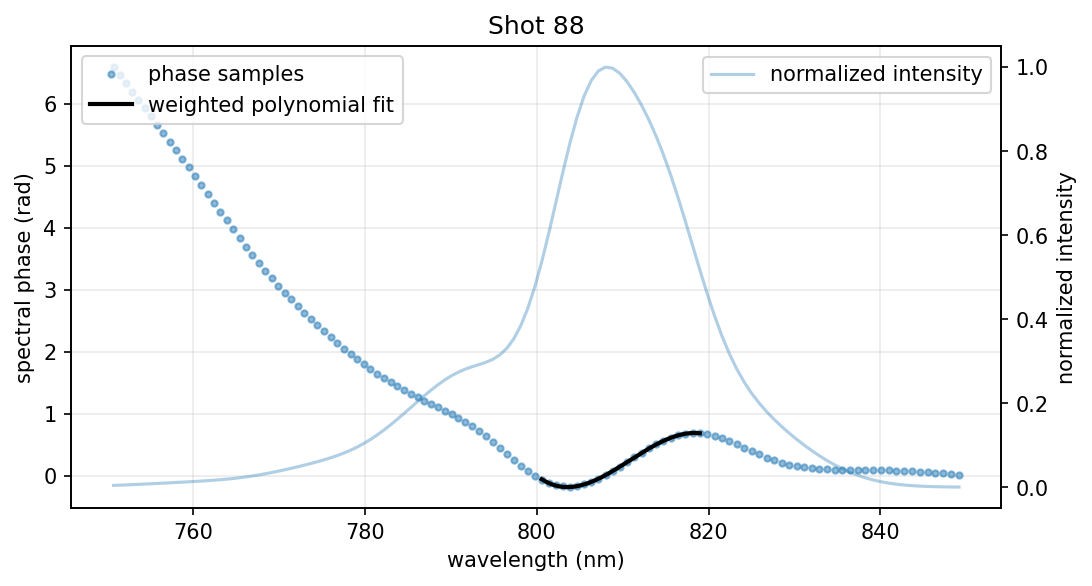

frog_spectral_phase_tod_fs3     137415.724921
frog_spectral_phase_gdd_fs2       4345.833110
frog_spectral_phase_gd_fs           37.849096
frog_spectral_phase_phi0_rad        -8.500490
frog_spectral_phase_flipped          1.000000
dtype: float64

In [5]:
def _shot_number(path):
    match = re.search(r"_([0-9]+)_retrieved_lineouts$", path.stem)
    return int(match.group(1)) if match else None


sample_file = lineout_files[len(lineout_files) // 2]
sample_result = analyzer.analyze_image_file(sample_file)

# Post-refactor: line_data is the fixed-length fit (sorted by wavelength);
# raw scattered phase samples + intensity-weight curve live in render_data
# for single-shot inspection.
raw_wavelength = sample_result.render_data["raw_wavelength_nm"]
raw_phase = sample_result.render_data["raw_spectral_phase"]
fit_wavelength = sample_result.line_data[:, 0]
fit_phase = sample_result.line_data[:, 1]
normalized_weights = sample_result.render_data["fit_normalized_reference"]

fig, ax_phase = plt.subplots(figsize=(8, 4), dpi=150)
ax_weight = ax_phase.twinx()

ax_phase.plot(
    raw_wavelength,
    raw_phase,
    ".",
    alpha=0.5,
    label="phase samples",
)
ax_phase.plot(
    fit_wavelength,
    fit_phase,
    "k-",
    linewidth=2,
    label="weighted polynomial fit",
)
ax_weight.plot(
    raw_wavelength,
    normalized_weights,
    color="tab:blue",
    alpha=0.35,
    label="normalized intensity",
)

ax_phase.set_xlabel("wavelength (nm)")
ax_phase.set_ylabel("spectral phase (rad)")
ax_weight.set_ylabel("normalized intensity")
ax_phase.set_title(f"Shot {_shot_number(sample_file)}")
ax_phase.grid(True, alpha=0.25)
ax_phase.legend(loc="upper left")
ax_weight.legend(loc="upper right")
plt.show()

pd.Series(sample_result.scalars).filter(like="spectral_phase")

## Analyze The Scan

In [6]:
records = []
for path in lineout_files:
    result = analyzer.analyze_image_file(path)
    records.append({"shot": _shot_number(path), **result.scalars})

coeff_df = pd.DataFrame.from_records(records).set_index("shot").sort_index()
coeff_df.head()

,frog_spectral_phase_tod_fs3,frog_spectral_phase_gdd_fs2,frog_spectral_phase_gd_fs,frog_spectral_phase_phi0_rad,frog_spectral_phase_flipped
shot,,,,,
2,99578.788017,2081.143537,-9.096434,-12.298900,1.0
3,131521.434762,3035.675885,1.363919,-1.054756,1.0
4,142509.180225,3789.142600,22.117980,-0.672768,1.0
5,114029.455978,2598.161564,-1.110517,-0.995803,1.0
6,113232.248734,2580.112941,-0.718638,-0.968456,1.0


## Plot Physical Phase Terms

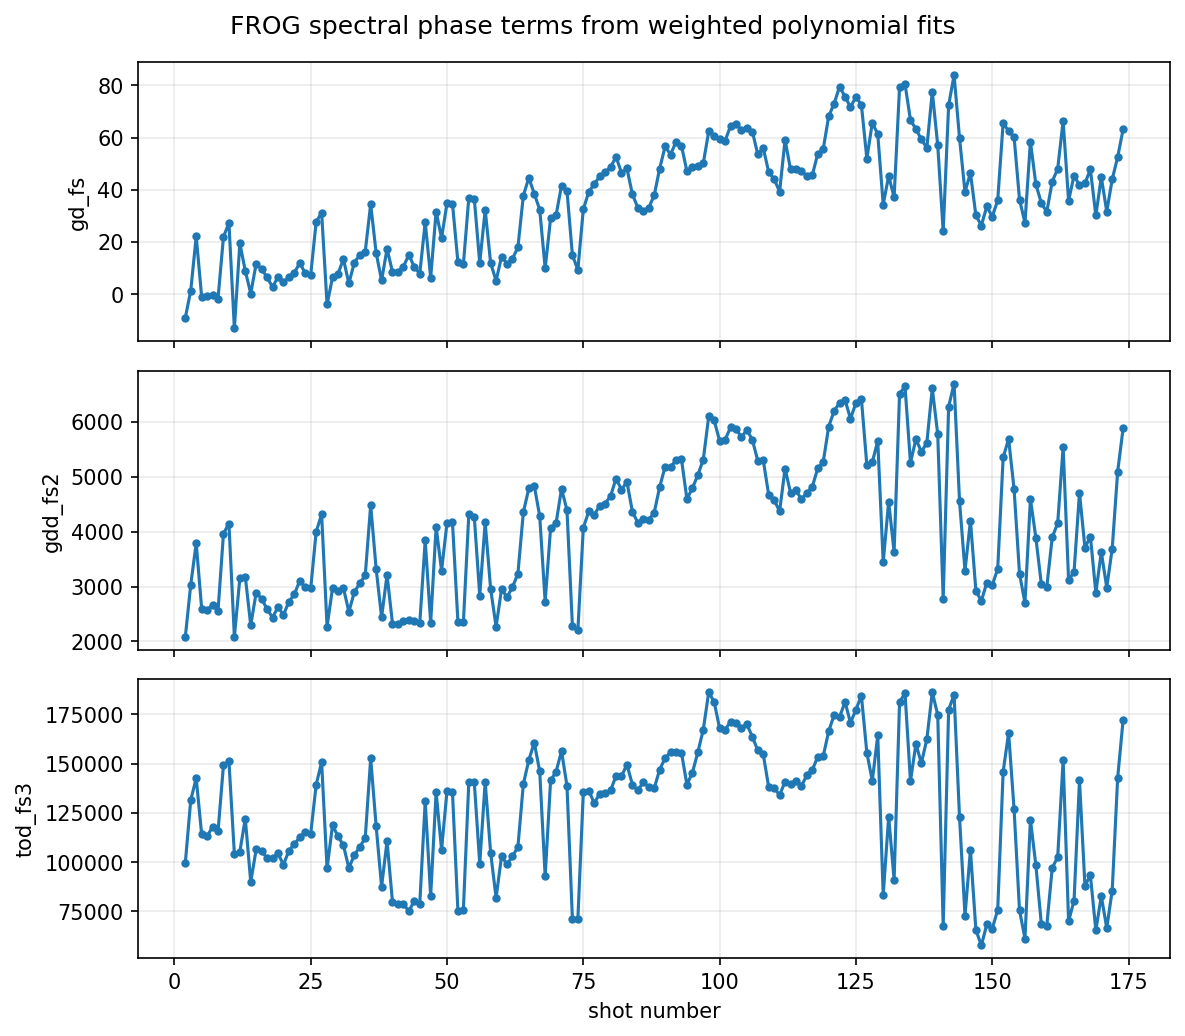

In [7]:
prefix = line_config.name
columns = [
    f"{prefix}_gd_fs",
    f"{prefix}_gdd_fs2",
    f"{prefix}_tod_fs3",
]

fig, axes = plt.subplots(len(columns), 1, figsize=(8, 7), dpi=150, sharex=True)
for ax, column in zip(axes, columns):
    ax.plot(coeff_df.index, coeff_df[column], "o-", markersize=3)
    ax.set_ylabel(column.replace(f"{prefix}_", ""))
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("shot number")
fig.suptitle("FROG spectral phase terms from weighted polynomial fits")
fig.tight_layout()
plt.show()

## Same Thing From A YAML Config

Everything above is shown the long way to keep the moving parts visible. In practice the analyzer's `Line1DConfig` lives in `GEECS-Plugins-Configs` — for this analyzer at `scan_analysis_configs/analyzers/HTU/U_FROG_Grenouille-SpectralPhase.yaml`. The YAML carries both an `image:` section (the `Line1DConfig` payload) and a `scan:` section (consumed by `Array1DScanAnalyzer` in production); standalone `load_line_config` unwraps the `image:` part transparently.

Per the PR-E loader API, the analyzer constructor takes a typed `Line1DConfig` — string-by-name resolution moved to the loader. The cell below loads the same config from disk and re-runs the analyzer; result should match the inline-config run.

In [8]:
from image_analysis.config import load_line_config

line_config_from_yaml = load_line_config("U_FROG_Grenouille-SpectralPhase")
analyzer_from_yaml = FrogSpectralPhaseAnalyzer(line_config=line_config_from_yaml)
config_result = analyzer_from_yaml.analyze_image_file(sample_file)

pd.Series(config_result.scalars)

U_FROG_Grenouille-SpectralPhase_tod_fs3     137415.724921
U_FROG_Grenouille-SpectralPhase_gdd_fs2       4345.833110
U_FROG_Grenouille-SpectralPhase_gd_fs           37.849096
U_FROG_Grenouille-SpectralPhase_phi0_rad        -8.500490
U_FROG_Grenouille-SpectralPhase_flipped          1.000000
dtype: float64